# Week 8 · Day 3 — Class
# Capstone: One Full Project, Start to Finish 🏆🐧

This is it — the last class. Today we run a **complete data project** end to end, the way you'd show it to an employer:

**Problem → Load → Clean → Explore → Visualize → Model → Result**

We'll use the **Palmer Penguins** dataset (predict a penguin's species from its body measurements). Watch how *every* skill from the last 8 weeks shows up in one flow.

Then in your assignment, you'll do this yourself — that's your capstone. 🚀

## 1. Problem statement

> **Can we predict a penguin's species from simple body measurements** (bill size, flipper length, body mass)?

A good project always starts with a clear question in plain English. Write yours down before any code.

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## 2. Load & inspect

Always look at shape, columns, and missing values first (Weeks 5–6 habits).

In [15]:
print("Shape:", penguins.shape)
print()
penguins.info()

Shape: (344, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [16]:
# Which columns have missing values?
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## 3. Clean (Week 6 skills)

A few rows have missing measurements. For a first project, dropping those few rows is fine and honest — we'll note it. Work on a `.copy()`.

In [17]:
df = penguins.copy()

# Drop rows with any missing values (only a handful here)
before = len(df)
df = df.dropna()
after = len(df)
print(f"Dropped {before - after} rows with missing data. {after} rows remain.")

Dropped 11 rows with missing data. 333 rows remain.


## 4. Explore & visualize (Week 7 skills)

A picture confirms the species really are separable — otherwise no model can help.

In [18]:
df["species"].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

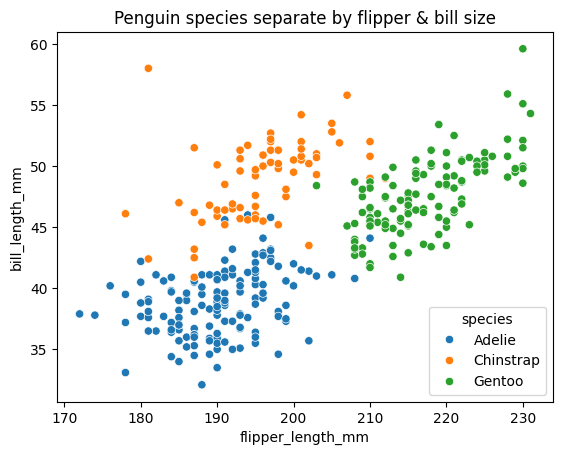

In [19]:
sns.scatterplot(data=df, x="flipper_length_mm", y="bill_length_mm", hue="species")
plt.title("Penguin species separate by flipper & bill size")
plt.show()

Clear clusters → a model can learn this. 👍

## 5. Prepare features for the model

We'll predict `species` from four numeric measurements. (We'll skip the text columns `island`/`sex` today to keep it simple — numeric features only.)

In [20]:
feature_cols = ["bill_length_mm", "bill_depth_mm",
                "flipper_length_mm", "body_mass_g"]

X = df[feature_cols]
y = df["species"]

print("Features:", feature_cols)
print("X shape:", X.shape, "| y shape:", y.shape)

Features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X shape: (333, 4) | y shape: (333,)


## 6. The 5-step ML recipe

In [27]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = KNeighborsClassifier(n_neighbors=8)
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Score
acc = accuracy_score(y_test, preds)
print(f"Accuracy: {acc*100:.1f}%")

Accuracy: 83.6%


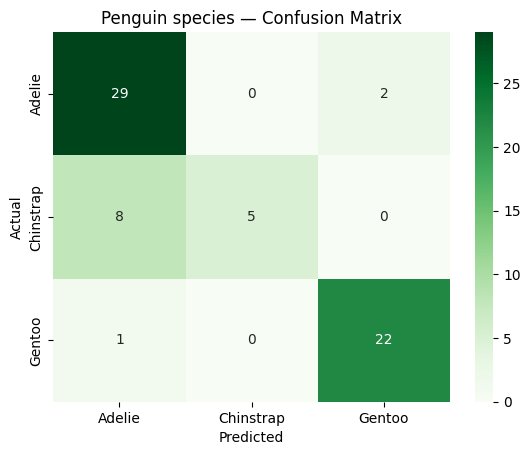

In [28]:
# Confusion matrix — where were the mistakes?
cm = confusion_matrix(y_test, preds, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Penguin species — Confusion Matrix")
plt.show()

## 7. Use the model

Predict the species of a new penguin from its measurements.

In [29]:
feature_cols

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

In [34]:
new_penguin = pd.DataFrame(
    [[10.0, 12.0, 310, 3000]],
    columns=feature_cols
)
print("Predicted species:", model.predict(new_penguin)[0])

Predicted species: Adelie


## 8. Result & conclusion (write it up)

This is what makes it a **portfolio project** and not just code — a short, honest write-up.

> **Result:** Using four body measurements, a KNN model predicted penguin species with about {acc}% accuracy. The confusion matrix shows most errors were between the two visually similar species. With more features (island, sex) accuracy could likely improve.

Every strong repo ends with a paragraph like this: **problem → approach → result.**

## 🎓 That's the whole course!

You just ran a real data project end to end. In your **capstone assignment**, you'll do exactly this — on your own choice of dataset (or the provided fallback).

Then push it to GitHub, polish your **profile README**, and pin your 6 best repos. You now have a portfolio. Be proud. 🏆🚀